np.float64(0.3008755181654492)

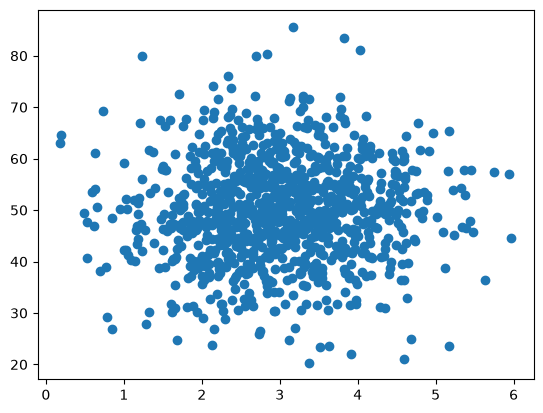

In [1]:
import numpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.pyplot import scatter

def de_mean(x):
    xmean = np.mean(x)
    return [xi - xmean for xi in x]   # devolvo o quanto cada ponto se afasta da media

def covariance(x,y):
    n = len(x)
    return np.dot(de_mean(x), de_mean(y)) / (n-1)   # multiplico os afastamentos e tiro a media deles

pageSpeeds = np.random.normal(3.0, 1.0, 1000)
purchaseAmount = np.random.normal(50.0, 10.0, 1000)   # gerei as duas separadas sem ligacao nenhuma

plt.scatter(pageSpeeds, purchaseAmount)   # a nuvem sai espalhada sem direcao

covariance(pageSpeeds, purchaseAmount)   # perto de zero confirma que nao se relacionam

np.float64(-0.020235837308473757)

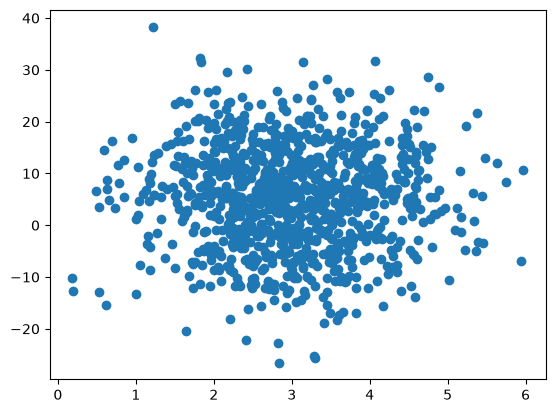

In [2]:
purchaseAmount = np.random.normal(5.0, 10.0, 1000)   # so mudei a media continua sem ligacao
plt.scatter(pageSpeeds, purchaseAmount)
covariance(pageSpeeds, purchaseAmount)   # segue perto de zero

np.float64(-0.9080749618357333)

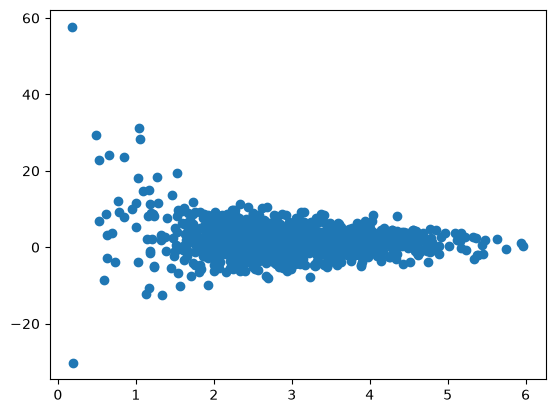

In [3]:
purchaseAmount = np.random.normal(5.0, 10.0, 1000) / pageSpeeds   # agora dividi por pageSpeeds e criei a ligacao
plt.scatter(pageSpeeds, purchaseAmount)   # a nuvem ganhou formato
covariance(pageSpeeds, purchaseAmount)   # o valor cresceu mas nao sei dizer se e forte
# porque a covariancia depende da escala das variaveis

In [4]:
def correlation(x,y):
    stddevx = x.std()
    stddevy = y.std()
    return covariance(x, y) / stddevx / stddevx   # aqui divido duas vezes pelo desvio de x

correlation(pageSpeeds, purchaseAmount)
# o resultado saiu fora do intervalo de -1 a 1 o que e impossivel pra correlacao
# achei o motivo na linha do return, ela ignora o stddevy que foi calculado logo acima
# o certo seria covariance(x, y) / stddevx / stddevy

np.float64(-0.989730127286966)

In [5]:
np.corrcoef(pageSpeeds, purchaseAmount)   # a funcao pronta devolve o valor dentro de -1 e 1
# e e essa saida que mostra o erro da minha funcao

array([[ 1.        , -0.19847325],
       [-0.19847325,  1.        ]])

np.float64(-3.0030030030030033)

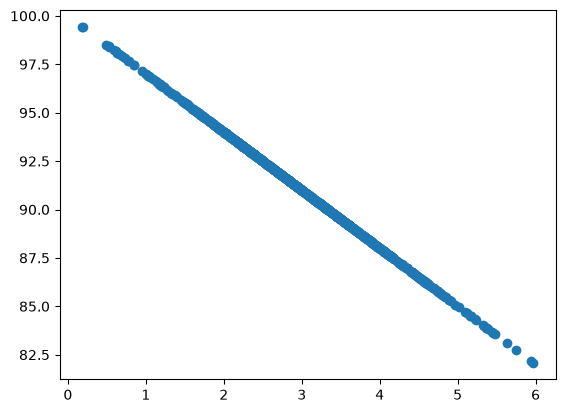

In [6]:
purchaseAmount = 100 - pageSpeeds * 3   # forcei uma reta perfeita sem nenhum ruido
plt.scatter(pageSpeeds, purchaseAmount)   # os pontos ficam todos em cima da linha
correlation(pageSpeeds, purchaseAmount)   # relacao negativa porque quando um sobe o outro desce